# Proyecto 1 - Parte 1

## Pedro Pablo Sanín Trujillo - 202221527

## Parte 1 - Importación de librerías y preprocesamiento de los textos.

Primero explicaremos el funcionamiento del procesamiento en un documento individual y luego construiremos el pipeline para aplicar las transformaciones al conjunto de datos. Inicialmente, haremos el preprocesamiento de los textos del conjunto de entrenamiento. Luego, tokenizaremos el texto para dividirlo en palabras individuales. Finalmente, hacemos stemming para que las palabras con la misma raíz sean consideradas como la misma palabra. Note que, en general, no nos interesan las terminaciones de las palabras. Por ejemplo, en el contexto del problema, las palabras: compra, compras y compramos nos transmiten básicamente la misma información. Tomar estas palabras como diferentes hace que los modelos sean innecesariamente pesados y complicados.


- Tokenización: Usaremos ``word_tokenize`` de ``NLTK``.
- Stemming: Usaremos ``SnowballStemmer`` de ``NLTK`` con el idioma fijado en ``spanish``.



In [215]:
# Importación de librerías
import nltk
import pandas as pd
from imblearn.pipeline import Pipeline
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

nltk.download('punkt_tab')  # Descargamos el tokenizador de NLTK para poder usar word_tokenize
nltk.download('stopwords')  # Descargamos las stopwords de NLTK para poder filtrar palabras comunes

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/pedropablosanintrujillo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [216]:
df = pd.read_csv("data/train.csv")

data = df.copy(deep=True)

print(f"Documentos cargados: {len(data)}")
data.head()


Documentos cargados: 12000


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [217]:
data.describe(include=['object'])


/var/folders/bl/m8gd2pc14237m1mz5n7dg_nw0000gn/T/ipykernel_77477/2899086016.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,text,label
count,12000,12000
unique,12000,3
top,Lo pedí un martes por la noche y me llegó al d...,positivo
freq,1,4212


In [218]:
data["label"].value_counts()

label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64

Vemos que en este caso, no tenemos datos faltantes inválidos, además, el número de datos de cada categoría es mas o menos igual. Por lo que podemos proceder directamente a la tokenización y stemming. 

Luego identificamos las `stop words` en español presentes en el texto. Estas son palabras que no agregan significado al texto, como y, de, un, entre otras. 

Para procesar estas palabras, usamos ``stopwords`` de ``nltk.corpus`` Al final, construimos una función ``tokenizer_stemmer`` para aplicar la tokenización, stemming y eliminación de stopwords.

Asimismo, revisamos el conjunto de stopwords y eliminamos aquellas que expresen algo negativo, pues estas nos ayudan a clasificar correctamente los mensajes.

In [219]:
spanish_stopwords_completas = set(stopwords.words("spanish"))

palabras_negativas = {"no", "nunca", "jamás", "nadie", "ninguno","poco","ni"}

spanish_stopwords = spanish_stopwords_completas - palabras_negativas

print(f"Cantidad de stopwords en español: {len(spanish_stopwords)}")
print(f"Contiene no: {'no' in spanish_stopwords}")
print(spanish_stopwords)

Cantidad de stopwords en español: 310
Contiene no: False
{'estén', 'hube', 'habré', 'a', 'hayas', 'nosotras', 'hubiesen', 'seríais', 'tuya', 'estuviésemos', 'tendrás', 'tendría', 'suyos', 'habrá', 'sois', 'todo', 'tuviese', 'estuvieras', 'mi', 'habría', 'yo', 'será', 'se', 'estábamos', 'los', 'un', 'tendrán', 'fuesen', 'tuvieras', 'la', 'tendrían', 'este', 'estarán', 'tuviéramos', 'estuvieron', 'han', 'estados', 'estando', 'suya', 'son', 'ellos', 'míos', 'habíais', 'que', 'estos', 'hubo', 'habríamos', 'estés', 'estuviste', 'otro', 'fueras', 'tenida', 'fuese', 'está', 'pero', 'teníamos', 'también', 'para', 'tenidos', 'donde', 'fuera', 'tenga', 'tengo', 'otros', 'sí', 'tendrá', 'hubisteis', 'estuvieseis', 'tiene', 'hasta', 'estaré', 'fueses', 'somos', 'nada', 'estáis', 'entre', 'estar', 'seremos', 'hayan', 'sentid', 'habidas', 'sentidos', 'tendréis', 'seréis', 'habrías', 'las', 'su', 'vosotras', 'eres', 'esa', 'o', 'tendrías', 'tenía', 'sentidas', 'seré', 'tuvisteis', 'habida', 'estaría'

In [220]:

stemmer = SnowballStemmer("spanish")


def tokenizer_stemmer(text, stopwords=spanish_stopwords):
    """Hacemos el preprocesamiento del texto: tokenización y stemming en una sola función para luego pasarlo al pipeline de procesamiento."""
    return [
        stemmer.stem(t)
        for t in word_tokenize(text.lower())
        if t.isalpha() and t not in stopwords
    ]

In [221]:
ejemplo = "Este es un ejemplo de texto para tokenización y stemming."
tokenizer_stemmer(ejemplo)

['ejempl', 'text', 'tokeniz', 'stemming']

## Parte 2 - Construcción del pipeline de preprocesamiento

A continuación, debemos construir una representación de nuestro texto que sea matemáticamente comprensible para nuestros modelos. Para hacer eso, usamos una representación en matrices dispersas. Para este propósito ``sk-learn`` ofrece varias formas de convertir nuestro texto en matrices dispersas.

- CountVectorizer: Produce una matriz dispersa 


In [222]:
TEXT_COLUMN = 'text'
COLUMN_LAST_SENTENCE = 'last_sentence'
TARGET_COLUMN = 'label'

VECTORIZERS = {
    'count': CountVectorizer,
    'tfidf': TfidfVectorizer,
}



def extract_last_sentence(text):
    """Extrae la última oración no vacía de un texto."""
    sentences = [s.strip() for s in text.split('.') if s.strip()]
    return sentences[-1] if sentences else ''


def add_last_sentence(X):
    """Agrega la columna con la última oración del texto, conservando las columnas originales."""
    return X.assign(**{COLUMN_LAST_SENTENCE: X[TEXT_COLUMN].apply(extract_last_sentence)})





def vectorizer_function(vectorizer='count'):
    return VECTORIZERS[vectorizer](tokenizer=tokenizer_stemmer, token_pattern=None, ngram_range=(1, 3))


def build_preprocessor(vectorizer='count'):
    """Construye el preprocesador de las features con el vectorizador indicado: 'count' o 'tfidf'.

    1. Crea la columna con la última oración.
    2. Crea la columna con la penúltima oración.
    3. Crea la columna con las dos últimas oraciones.
    4. Vectoriza por separado el texto completo, la última oración, la penúltima oración y las dos últimas oraciones.
    """
    return Pipeline([
        ('last_sentence', FunctionTransformer(add_last_sentence)),
        ('vectorizers', ColumnTransformer([
            ('text_vectorizer', vectorizer_function(vectorizer), TEXT_COLUMN),
            ('last_sentence_vectorizer', vectorizer_function(vectorizer), COLUMN_LAST_SENTENCE)
        ])),
    ])


preprocessor = build_preprocessor('count')
preprocessor

,steps,"[('last_sentence', ...), ('vectorizers', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...t 0x148a44180>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None


In [223]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ambos se ajustan solo con train
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)



print(f"X - Train: {X_train_transformed.shape} | Test: {X_test_transformed.shape}")



X - Train: (9600, 217840) | Test: (2400, 217840)


In [224]:
vectorizers = preprocessor.named_steps['vectorizers'].named_transformers_

for name in ['text_vectorizer', 'last_sentence_vectorizer']:
    print(f"Vocabulary size ({name}): {len(vectorizers[name].vocabulary_)}")

vocabulary = pd.DataFrame(vectorizers['text_vectorizer'].vocabulary_.items(), columns=['term', 'index'])
vocabulary

Vocabulary size (text_vectorizer): 172854
Vocabulary size (last_sentence_vectorizer): 44986


,term,index
0,compr,31243
1,hac,74269
2,par,111877
3,mes,95376
4,internet,80463
...,...,...
172849,agarr grand pas,2462
172850,grand pas boton,72350
172851,encend mantuv liger,57908
172852,mantuv liger dia,90328


## Entrenamiento del modelo

Accuracy: 0.8658333333333333
              precision    recall  f1-score   support

    negativo       0.80      0.82      0.81       843
     neutral       0.99      0.99      0.99       715
    positivo       0.82      0.80      0.81       842

    accuracy                           0.87      2400
   macro avg       0.87      0.87      0.87      2400
weighted avg       0.87      0.87      0.87      2400



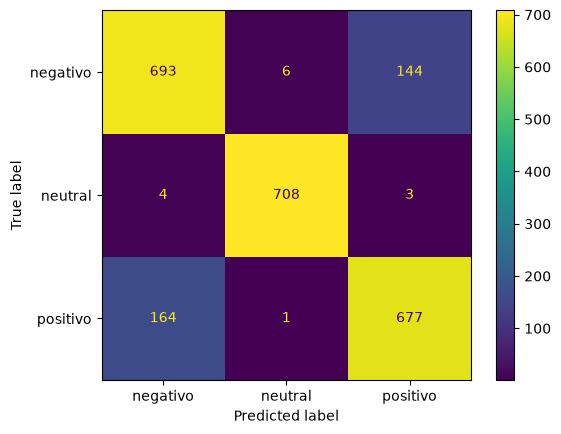

In [225]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_transformed, y_train)

y_pred = model.predict(X_test_transformed)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


Accuracy2: 0.605
              precision    recall  f1-score   support

    negativo       0.49      0.88      0.63       843
     neutral       0.83      0.80      0.82       715
    positivo       0.73      0.17      0.28       842

    accuracy                           0.60      2400
   macro avg       0.68      0.61      0.57      2400
weighted avg       0.67      0.60      0.56      2400



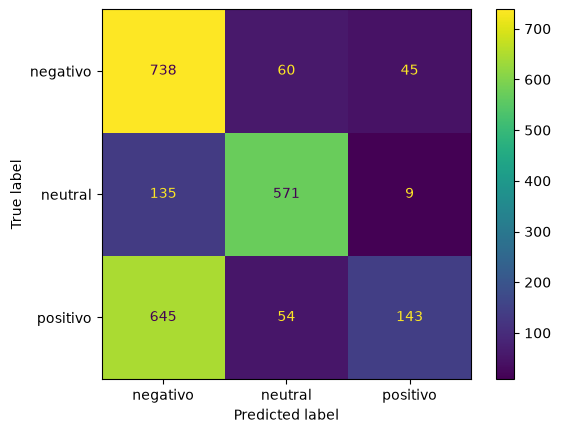

In [226]:
model2 = DecisionTreeClassifier(max_depth=10)
model2.fit(X_train_transformed, y_train)
y_pred2 = model2.predict(X_test_transformed)

accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Accuracy2: {accuracy2}")
print(classification_report(y_test, y_pred2))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)
plt.show()